# Clase 8 — Ambigüedad Lingüística y Transición al Análisis Semántico
### Actividad 8 · Procesamiento de Lenguaje Natural · Maestría en Inteligencia Artificial (UPMH)

**Alumno:** Víctor Manuel Santos Martínez · **Matrícula:** 253220020 · **Grupo:** 3.º A
**Docente:** M.C. Pablo Ricardo Sánchez Gómez · **Corte:** 2 · Unidad 3.1

---

## Objetivo del cuaderno

Reproducir, documentar y **enriquecer visualmente** el análisis automático de ambigüedad
lingüística provisto por el docente. El cuaderno detecta y clasifica señales de ambigüedad
**léxica**, **sintáctica** y **semántica** sobre un dataset de 72 oraciones en español, exporta
seis archivos `.csv` verificables y genera las figuras que sustentan el informe de evidencias.

> **Postura metodológica (idea central de la clase):** la ambigüedad *no es un error* del
> lenguaje, sino una propiedad natural que el sistema debe **detectar y administrar con
> evidencia**, no "arreglar". El programa produce *hipótesis* señalando candidatos; la
> interpretación final es responsabilidad del analista humano.


## 1. Fundamento teórico condensado

| Nivel | Dónde surge | Ejemplo del dataset | Señal que rastrea el sistema |
|:--|:--|:--|:--|
| **Léxico** | En la palabra | *"El **banco** aprobó el crédito"* | Palabras polisémicas/homónimas de una lista curada |
| **Sintáctico** | En la estructura | *"Vi al estudiante **con el telescopio**"* | Preposiciones → posible adjunción ambigua |
| **Semántico** | En el significado | *"**Todos** los alumnos **no** entregaron"* | Cuantificadores, negación, anáfora, roles |

El pipeline conceptual de la sesión tiene 6 pasos: **Dataset → Normalización → Señales léxicas
→ Señales sintácticas → Señales semánticas → Revisión humana**. Este cuaderno automatiza los
pasos 1–5 y *prepara* el paso 6 mediante un puntaje de prioridad de revisión.


## 2. Configuración e importaciones

Se usan únicamente componentes de la biblioteca estándar para el motor de reglas (fiel al script
del docente) más `pandas`/`matplotlib` para tabulación y visualización. Se evita `spaCy` de forma
deliberada: la propia clase advierte sobre *"sobreconfiar en los modelos"*, y el objetivo aquí es
un detector de señales **transparente y auditable**.


In [1]:
import csv, re, unicodedata
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "datos" / "oraciones_clase8.csv"
SALIDA = BASE / "salidas_clase8"; SALIDA.mkdir(exist_ok=True)
FIGURAS = BASE / "figuras"; FIGURAS.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
print("Entrada:", ENTRADA.name, "| ¿existe?", ENTRADA.exists())

Entrada: oraciones_clase8.csv | ¿existe? True


## 3. Recursos lingüísticos (léxicos controlados)

Tres conjuntos actúan como *knowledge base* mínima del detector. Su carácter finito y explícito
es una decisión de diseño: hace **reproducible y explicable** cada marca del sistema.


In [2]:
# Palabras con más de un sentido (homonimia/polisemia) frecuentes en español
PALABRAS_AMBIGUAS = {'banco','planta','cura','capital','raton','gato','sierra','vela',
                     'curso','red','copa','columna','radio','clave','linea','cabo'}

# Preposiciones que suelen introducir adjunción ambigua de sintagma preposicional
PREPOSICIONES = {'con','en','de','por','para','sobre','entre'}

# Marcadores de conflicto semántico: cuantificadores, negación, pronombres, conectores causales
SENALES_SEMANTICAS = {'todos','no','pocos','muchas','su','sus','ella','ellos','lo','la',
                      'porque','cuando','aunque','antes','despues'}

## 4. Normalización del texto

**Regla de oro (paso 2 del pipeline):** limpiar *sin destruir información*. Se pasa a minúsculas,
se eliminan acentos vía `NFD` (para que `ratón`≈`raton` haga match con el léxico) y se retira la
puntuación conservando letras, dígitos, `ñ` y guiones. Se preserva el texto original para el
reporte; la versión limpia solo alimenta al detector.


In [3]:
def limpiar(texto: str) -> str:
    """Minúsculas + sin acentos + sin puntuación; conserva ñ, dígitos y guiones."""
    texto = texto.strip().lower()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                    if unicodedata.category(c) != 'Mn')
    texto = re.sub(r'[^a-zñ0-9\s-]', ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()

def tokenizar(texto: str) -> list:
    return [t for t in limpiar(texto).split() if t]

def contexto(toks, i, v=3):
    """Ventana de +/- v tokens alrededor de la posición i (contexto local)."""
    return ' '.join(toks[max(0, i - v):min(len(toks), i + v + 1)])

# Prueba rápida
demo = "El banco aprobó el crédito."
print("Limpio :", limpiar(demo))
print("Tokens :", tokenizar(demo))

Limpio : el banco aprobo el credito
Tokens : ['el', 'banco', 'aprobo', 'el', 'credito']


## 5. Motor de análisis por señales

Recorre cada oración una sola vez y produce cinco vistas: dataset validado, indicios léxicos,
sintácticos y semánticos, y un puntaje de prioridad de revisión humana.

El **puntaje** pondera qué tan "cargada" de señales está una oración:
`2` si contiene palabra ambigua `+1` si tiene preposiciones `+1` si tiene marcadores semánticos
`+1` base. A mayor puntaje, mejor candidata para el análisis manual del paso 6.


In [4]:
with open(ENTRADA, encoding='utf-8-sig', newline='') as f:
    data = list(csv.DictReader(f))

valid, lex, sint, sem, muestra = [], [], [], [], []
resumen = Counter()

for r in data:
    toks = tokenizar(r['texto']); tipo = r['tipo_ambiguedad']; resumen[tipo] += 1
    valid.append({'id': r['id'], 'texto_original': r['texto'],
                  'texto_limpio': limpiar(r['texto']), 'tokens': ' | '.join(toks),
                  'tipo_ambiguedad': tipo, 'fenomeno': r['fenomeno'], 'dominio': r['dominio']})
    preps = [t for t in toks if t in PREPOSICIONES]
    sems = [t for t in toks if t in SENALES_SEMANTICAS]
    for i, t in enumerate(toks):
        if t in PALABRAS_AMBIGUAS:
            lex.append({'id': r['id'], 'texto': r['texto'], 'palabra_ambigua': t,
                        'contexto_local': contexto(toks, i), 'tipo_esperado': tipo,
                        'interpretacion_requerida': 'Seleccionar sentido con base en contexto y dominio.'})
    if preps:
        sint.append({'id': r['id'], 'texto': r['texto'],
                     'preposiciones_detectadas': ' | '.join(preps), 'num_preposiciones': len(preps),
                     'tipo_esperado': tipo,
                     'posible_problema': 'Adjunción de sintagma preposicional o complemento con más de una lectura.'})
    if sems:
        sem.append({'id': r['id'], 'texto': r['texto'], 'senales_semanticas': ' | '.join(sems),
                    'tipo_esperado': tipo,
                    'posible_problema': 'Revisar referencia, alcance, cuantificador, causalidad o roles.'})
    score = (2 if any(t in PALABRAS_AMBIGUAS for t in toks) else 0) + (1 if preps else 0) + (1 if sems else 0) + 1
    muestra.append({'id': r['id'], 'texto': r['texto'], 'tipo_ambiguedad': tipo,
                    'fenomeno': r['fenomeno'], 'puntaje_revision': score,
                    'uso_sugerido': 'Seleccionar para muestra si representa claramente el tipo de ambigüedad.'})

print("Oraciones procesadas:", len(data))
print("Indicios -> léxicos:", len(lex), "| sintácticos:", len(sint), "| semánticos:", len(sem))

Oraciones procesadas: 72
Indicios -> léxicos: 24 | sintácticos: 38 | semánticos: 52


## 6. Exportación de las 6 salidas verificables

Se escriben en `utf-8-sig` para que Excel respete los acentos. Son los archivos que el docente
solicita como evidencia reproducible.


In [5]:
def escribir(path, rows, fns):
    with open(path, 'w', encoding='utf-8-sig', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fns); w.writeheader(); w.writerows(rows)

escribir(SALIDA/'01_dataset_validado.csv', valid,
         ['id','texto_original','texto_limpio','tokens','tipo_ambiguedad','fenomeno','dominio'])
escribir(SALIDA/'02_indicios_lexicos.csv', lex,
         ['id','texto','palabra_ambigua','contexto_local','tipo_esperado','interpretacion_requerida'])
escribir(SALIDA/'03_indicios_sintacticos.csv', sint,
         ['id','texto','preposiciones_detectadas','num_preposiciones','tipo_esperado','posible_problema'])
escribir(SALIDA/'04_indicios_semanticos.csv', sem,
         ['id','texto','senales_semanticas','tipo_esperado','posible_problema'])
escribir(SALIDA/'05_resumen_por_tipo.csv',
         [{'tipo_ambiguedad': k, 'total': v} for k, v in sorted(resumen.items())],
         ['tipo_ambiguedad','total'])
escribir(SALIDA/'06_muestra_sugerida.csv',
         sorted(muestra, key=lambda x: (x['tipo_ambiguedad'], -int(x['puntaje_revision']), int(x['id']))),
         ['id','texto','tipo_ambiguedad','fenomeno','puntaje_revision','uso_sugerido'])
print("6 archivos .csv escritos en:", SALIDA.resolve())

6 archivos .csv escritos en: /Users/victor/Library/Mobile Documents/com~apple~CloudDocs/Maestría UMPH/Cuatrimestre 3/Procesamiento De Lenguaje Natural/Actividad 8/codigo_datos_clase8/salidas_clase8


## 7. Vistas tabulares rápidas (control de calidad)

In [6]:
df_valid = pd.DataFrame(valid)
display(df_valid.head(8))
print("\nResumen por tipo:")
display(pd.Series(resumen).rename('total').to_frame())

,id,texto_original,texto_limpio,tokens,tipo_ambiguedad,fenomeno,dominio
0,1,El banco aprobó el crédito,el banco aprobo el credito,el | banco | aprobo | el | credito,lexica,banco,economía
1,2,El banco del parque estaba mojado,el banco del parque estaba mojado,el | banco | del | parque | estaba | mojado,lexica,banco,vida cotidiana
2,3,La planta requiere agua cada mañana,la planta requiere agua cada manana,la | planta | requiere | agua | cada | manana,lexica,planta,biología
3,4,La planta industrial cerró temprano,la planta industrial cerro temprano,la | planta | industrial | cerro | temprano,lexica,planta,economía
4,5,El cura habló con los vecinos,el cura hablo con los vecinos,el | cura | hablo | con | los | vecinos,lexica,cura,social
5,6,La cura redujo el dolor del paciente,la cura redujo el dolor del paciente,la | cura | redujo | el | dolor | del | paciente,lexica,cura,salud
6,7,La capital recibió inversión extranjera,la capital recibio inversion extranjera,la | capital | recibio | inversion | extranjera,lexica,capital,economía
7,8,El capital de la empresa aumentó,el capital de la empresa aumento,el | capital | de | la | empresa | aumento,lexica,capital,economía



Resumen por tipo:


,total
lexica,24
sintactica,24
semantica,24


## 8. Visualizaciones para el informe

Cada figura se exporta a `figuras/*.png` y se incrusta luego en la nota de Obsidian con su pie
numerado. Las gráficas resumen la evidencia agregada, no sustituyen el análisis caso por caso.


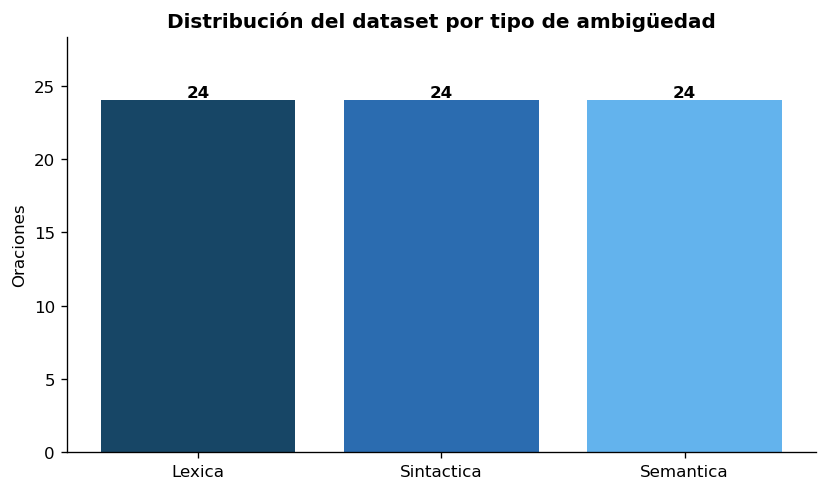

In [7]:
orden = ['lexica','sintactica','semantica']
PAL = {'lexica':'#174666','sintactica':'#2b6cb0','semantica':'#63b3ed'}

# Fig 1 - Distribución del dataset
fig, ax = plt.subplots(figsize=(7,4.2))
vals = [resumen[k] for k in orden]
ax.bar([k.capitalize() for k in orden], vals, color=[PAL[k] for k in orden])
for i,v in enumerate(vals): ax.text(i, v+0.2, str(v), ha='center', fontweight='bold')
ax.set_title('Distribución del dataset por tipo de ambigüedad'); ax.set_ylabel('Oraciones')
ax.set_ylim(0, max(vals)*1.18); fig.tight_layout()
fig.savefig(FIGURAS/'a8_fig1_distribucion_dataset.png'); plt.show()

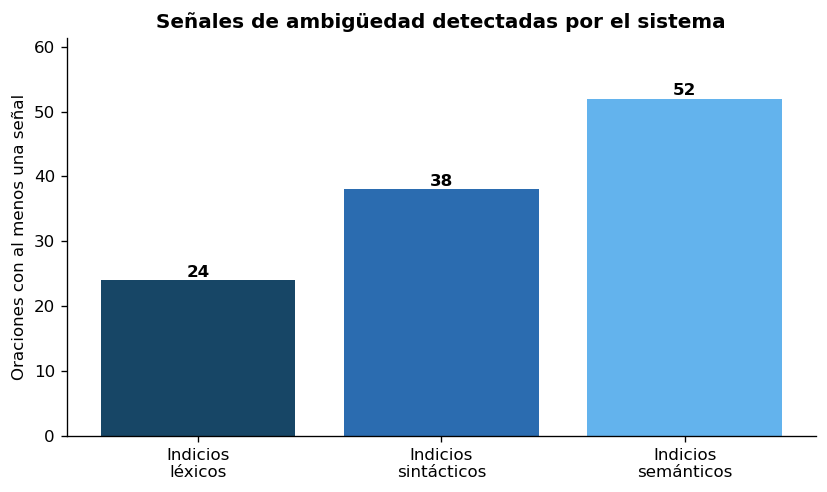

In [8]:
# Fig 2 - Señales detectadas por categoría
cat = {'Indicios\nléxicos': len(lex), 'Indicios\nsintácticos': len(sint), 'Indicios\nsemánticos': len(sem)}
fig, ax = plt.subplots(figsize=(7,4.2))
ax.bar(list(cat), list(cat.values()), color=['#174666','#2b6cb0','#63b3ed'])
for i,v in enumerate(cat.values()): ax.text(i, v+0.5, str(v), ha='center', fontweight='bold')
ax.set_title('Señales de ambigüedad detectadas por el sistema')
ax.set_ylabel('Oraciones con al menos una señal'); ax.set_ylim(0, max(cat.values())*1.18)
fig.tight_layout(); fig.savefig(FIGURAS/'a8_fig2_indicios_por_categoria.png'); plt.show()

In [9]:
# Fig 3 y 4 se generan igualmente; para el informe se usa el script reproducible:
#   python generar_figuras.py
# que produce las 5 figuras a partir de los .csv ya exportados.
import subprocess, sys
print('Sugerencia: ejecutar generar_figuras.py para regenerar las 5 figuras de forma idempotente.')

Sugerencia: ejecutar generar_figuras.py para regenerar las 5 figuras de forma idempotente.


## 9. Muestra procesada (5 léxicas + 5 sintácticas + 5 semánticas)

Selección equilibrada solicitada como evidencia E03, mostrando la salida del programa por caso.


In [10]:
ids_muestra = ['1','3','11','13','19',   # léxicas
               '25','26','28','38','43',  # sintácticas
               '49','50','55','56','63']  # semánticas
df_muestra = df_valid[df_valid['id'].isin(ids_muestra)].copy()
df_muestra['id'] = df_muestra['id'].astype(int)
display(df_muestra.sort_values('id')[['id','texto_original','tipo_ambiguedad','fenomeno','dominio']])

,id,texto_original,tipo_ambiguedad,fenomeno,dominio
0,1,El banco aprobó el crédito,lexica,banco,economía
2,3,La planta requiere agua cada mañana,lexica,planta,biología
10,11,El gato levantó el automóvil,lexica,gato,mecánica
12,13,La sierra cortó la madera,lexica,sierra,herramientas
18,19,La red presentó fallas de conexión,lexica,red,tecnología
24,25,Vi al estudiante con el telescopio,sintactica,adjunción preposicional,educación
25,26,La alumna observó al investigador con la cámara,sintactica,adjunción preposicional,investigación
27,28,El docente revisó el reporte con errores,sintactica,adjunción preposicional,educación
37,38,El médico atendió al paciente con fiebre,sintactica,adjunción preposicional,salud
42,43,El profesor observó a la estudiante con lentes,sintactica,adjunción preposicional,educación


## 10. Conclusión técnica

El sistema procesó **72 oraciones** (24 por tipo) y marcó **24** indicios léxicos, **38**
sintácticos y **52** semánticos: la ambigüedad semántica genera más señales porque cuantificadores,
negación y anáfora coexisten en una misma oración. La lección central —*"interpretar es más difícil
que ejecutar"*— se materializa aquí: el detector **señala candidatos con evidencia contextual**
(palabra + contexto local, preposición, marcador semántico), pero la resolución exige criterio
humano, sobre todo en el nivel semántico, donde el modelo carece del conocimiento del mundo para
desempatar. El valor del pipeline no es "entenderlo todo", sino **reconocer cuándo una salida
automática basta y cuándo es obligatoria la revisión humana**.
